In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Better looking plots
plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/updated.csv")
#df.head()
#df.tail()
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 2442
Columns : 20


In [3]:
df.columns

Index(['Unnamed: 0', 'ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Time_Orderd', 'Time_Order_picked',
       'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition',
       'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival',
       'City', 'Time_taken(min)'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2442 entries, 0 to 2441
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   2442 non-null   int64  
 1   ID                           2442 non-null   str    
 2   Delivery_person_ID           2442 non-null   str    
 3   Delivery_person_Age          2442 non-null   int64  
 4   Delivery_person_Ratings      2348 non-null   float64
 5   Restaurant_latitude          2442 non-null   float64
 6   Restaurant_longitude         2442 non-null   float64
 7   Delivery_location_latitude   2442 non-null   float64
 8   Delivery_location_longitude  2442 non-null   float64
 9   Time_Orderd                  2353 non-null   str    
 10  Time_Order_picked            2442 non-null   str    
 11  Weatherconditions            2442 non-null   int64  
 12  Road_traffic_density         2442 non-null   int64  
 13  Vehicle_condition            

In [5]:
df.describe()

,Unnamed: 0,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
count,2442.000000,2442.000000,2348.000000,2442.000000,2442.000000,2442.000000,2442.000000,2442.000000,2442.000000,2442.000000,2442.000000,2442.000000,2388.000000,2442.000000,2442.000000,2442.000000
mean,1221.500000,28.404996,4.630111,17.153256,71.030894,17.579366,71.479728,2.694922,1.742424,0.993857,1.497952,3.253481,0.762563,1.027846,1.540131,26.487715
std,705.089001,8.026137,0.315338,8.007773,21.512859,7.183449,20.199970,2.011206,1.004493,0.835241,1.127746,0.592903,0.557680,0.189985,0.925440,9.339518
min,1.000000,0.000000,2.500000,-30.902872,-85.335486,0.010000,0.010000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,10.000000
25%,611.250000,24.000000,4.500000,12.933284,73.170937,12.990346,73.415482,1.000000,1.000000,0.000000,0.000000,3.000000,0.000000,1.000000,1.000000,20.000000
50%,1221.500000,29.000000,4.700000,18.562450,76.282198,18.663646,76.334069,3.000000,2.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,26.000000
75%,1831.750000,34.000000,4.800000,22.728163,78.053957,22.783839,78.127778,4.000000,2.000000,2.000000,3.000000,4.000000,1.000000,1.000000,3.000000,32.000000
max,2442.000000,50.000000,6.000000,30.914057,88.433452,31.035562,88.503310,7.000000,5.000000,3.000000,3.000000,4.000000,3.000000,3.000000,4.000000,54.000000


In [6]:
df.describe(include="object")

C:\Users\Saurabh Choudhary\AppData\Local\Temp\ipykernel_22608\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,ID,Delivery_person_ID,Time_Orderd,Time_Order_picked
count,2442,2442,2353,2442
unique,2441,967,175,192
top,0x38c6_x,HYDRES18DEL02,20:35,19:40
freq,2,9,37,36


In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
Delivery_person_Ratings,94,3.85
Time_Orderd,89,3.64
multiple_deliveries,54,2.21
Unnamed: 0,0,0.00
Delivery_person_Age,0,0.00
Delivery_person_ID,0,0.00
ID,0,0.00
Restaurant_longitude,0,0.00
Delivery_location_latitude,0,0.00
Delivery_location_longitude,0,0.00


In [8]:
print(df.duplicated().sum())


0


In [9]:
for col in df.select_dtypes(include="object").columns:
    print("="*40)
    print(col)
    print(df[col].unique())

ID
<StringArray>
['0x4607_x', '0xb379_x', '0x20f7_x', '0x7804_x', '0x7faf_x', '0x5218_x',
 '0xcafe_x', '0x8c03_x', '0xceec_x', '0x38c6_x',
 ...
   '0x4607', '0xb379_y', '0x20f7_y', '0x7804_y', '0x7faf_y', '0x5218_y',
 '0xcafe_y', '0x8c03_y', '0xceec_y',   '0xdf0d']
Length: 2441, dtype: str
Delivery_person_ID
<StringArray>
[  'INDORES13DEL02',   'BANGRES18DEL02',   'BANGRES18DEL01',
    'HYDRES13DEL02', 'RANCHIRES07DEL01',   'BANGRES02DEL02',
    'ALHRES13DEL02',  'COIMBRES09DEL01',    'KNPRES04DEL03',
    'JAPRES11DEL01',
 ...
    'KOLRES17DEL02',    'AGRRES18DEL03',   'LUDHRES02DEL02',
    'KOLRES19DEL03',    'GOARES16DEL01',   'BANGRES06DEL03',
    'VADRES06DEL01',   'PUNERES12DEL01',   'HYDRES010DEL01',
    'DEHRES18DEL03']
Length: 967, dtype: str
Time_Orderd
<StringArray>
['11:30', '19:45', '13:50', '10:60', '23:50', '17:60', '22:15', '18:30',
 '17:50', '13:20',
 ...
 '12:20', '13:60', '16:10', '16:40', '15:40', '13:25', '14:30', '12:25',
 '13:35', '16:20']
Length: 176, dtype: str


C:\Users\Saurabh Choudhary\AppData\Local\Temp\ipykernel_22608\241285287.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [10]:
for col in df.select_dtypes(include="object").columns:
    print(col)
    print(df[col].value_counts())
    print()

ID
ID
0x38c6_x    2
0x4607_x    1
0xb379_x    1
0x20f7_x    1
0x7804_x    1
           ..
0x5218_y    1
0xcafe_y    1
0x8c03_y    1
0xceec_y    1
0xdf0d      1
Name: count, Length: 2441, dtype: int64

Delivery_person_ID
Delivery_person_ID
HYDRES18DEL02     9
BANGRES05DEL02    8
BANGRES08DEL02    8
MUMRES11DEL01     8
BANGRES18DEL01    7
                 ..
BANGRES06DEL03    1
VADRES06DEL01     1
PUNERES12DEL01    1
HYDRES010DEL01    1
DEHRES18DEL03     1
Name: count, Length: 967, dtype: int64

Time_Orderd
Time_Orderd
20:35    37
22:35    34
19:50    32
23:55    31
23:50    30
         ..
12:35     1
16:60     1
12:25     1
13:35     1
16:20     1
Name: count, Length: 175, dtype: int64

Time_Order_picked
Time_Order_picked
19:40    36
24:05    35
20:50    32
21:45    30
20:30    30
         ..
16:30     1
14:35     1
14:25     1
14:55     1
12:35     1
Name: count, Length: 192, dtype: int64



C:\Users\Saurabh Choudhary\AppData\Local\Temp\ipykernel_22608\2680942102.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [11]:
df["Time_taken(min)"].describe()

count    2442.000000
mean       26.487715
std         9.339518
min        10.000000
25%        20.000000
50%        26.000000
75%        32.000000
max        54.000000
Name: Time_taken(min), dtype: float64

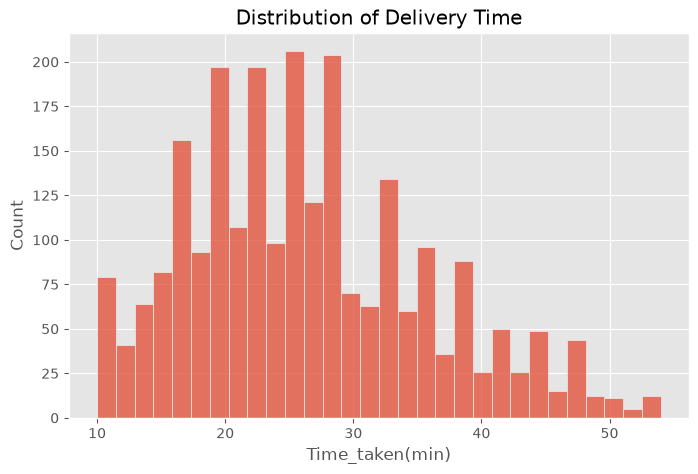

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Time_taken(min)"], bins=30)

plt.title("Distribution of Delivery Time")

plt.show()

In [13]:
numerical = df.select_dtypes(include=np.number)

numerical.head()

,Unnamed: 0,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,1,37,4.9,22.745049,75.892471,22.765049,75.912471,4,0,2,3,3,0.0,1,3,24.0
1,2,34,4.5,12.913041,77.683237,13.043041,77.813237,3,1,2,3,4,1.0,1,1,33.0
2,3,37,4.4,12.913041,77.683237,12.953041,77.723237,6,0,0,0,3,2.0,1,1,42.0
3,4,28,4.9,17.431477,78.400350,17.451477,78.420350,2,2,1,2,4,1.0,1,3,19.0
4,5,37,4.6,23.359407,85.325055,23.429407,85.395055,3,2,0,2,3,1.0,1,1,25.0


In [14]:
numerical.columns

Index(['Unnamed: 0', 'Delivery_person_Age', 'Delivery_person_Ratings',
       'Restaurant_latitude', 'Restaurant_longitude',
       'Delivery_location_latitude', 'Delivery_location_longitude',
       'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition',
       'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival',
       'City', 'Time_taken(min)'],
      dtype='str')

In [15]:
categorical = df.select_dtypes(include="object")

categorical.columns

C:\Users\Saurabh Choudhary\AppData\Local\Temp\ipykernel_22608\2001309247.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include="object")


Index(['ID', 'Delivery_person_ID', 'Time_Orderd', 'Time_Order_picked'], dtype='str')

In [16]:
# Check invalid ages
print(df[df["Delivery_person_Age"] <= 0])

# Check ratings greater than 5
print(df[df["Delivery_person_Ratings"] > 5])

# Check duplicate IDs
print(df[df["ID"].duplicated(keep=False)])

      Unnamed: 0      ID Delivery_person_ID  Delivery_person_Age  \
24            25  0x6192  RANCHIRES010DEL03                    0   
74            75  0x13ac      VADRES01DEL02                    0   
85            86  0xd0d0      KNPRES13DEL01                    0   
115          116  0x18b9   RANCHIRES19DEL03                    0   
186          187   0x644     BANGRES04DEL02                    0   
...          ...     ...                ...                  ...   
2232        2233   0x6ec      MYSRES11DEL01                    0   
2286        2287  0x1087      HYDRES14DEL01                    0   
2295        2296   0x4b0      HYDRES18DEL02                    0   
2315        2316   0x726     CHENRES19DEL03                    0   
2357        2358   0x741      VADRES07DEL01                    0   

      Delivery_person_Ratings  Restaurant_latitude  Restaurant_longitude  \
24                        NaN            23.354422             85.332900   
74                        NaN  